In [2]:
!pip install nltk

In [4]:
import nltk

# **Data Loading**

In [14]:
from sklearn.datasets import fetch_20newsgroups

# Load the dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

# Access data and labels
print("Sample Article:", newsgroups_train.data[0])
print("Category:", newsgroups_train.target_names[newsgroups_train.target[0]])


Sample Article: I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.
Category: rec.autos


In [6]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Add this line to download the required resource

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# Preprocessing function
def preprocess_text(text):
  # Convert to lowercase
  text = text.lower()
  # Remove non-alphanumeric characters (excluding spaces)
  text = re.sub(r'[^a-z0-9\s]', '', text)
  # Tokenize the text
  tokens = word_tokenize(text)
  # Remove stopwords
  tokens = [word for word in tokens if word not in stopwords.words('english')]
  return ' '.join(tokens)

# Apply preprocessing to the datasets
newsgroups_train_preprocessed = [preprocess_text(text) for text in newsgroups_train.data]
newsgroups_test_preprocessed = [preprocess_text(text) for text in newsgroups_test.data]

print("\nSample Preprocessed Article:", newsgroups_train_preprocessed[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Sample Preprocessed Article: wondering anyone could enlighten car saw day 2door sports car looked late 60s early 70s called bricklin doors really small addition front bumper separate rest body know anyone tellme model name engine specs years production car made history whatever info funky looking car please email


In [13]:
newsgroups_train.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

# **Data Visulaization**

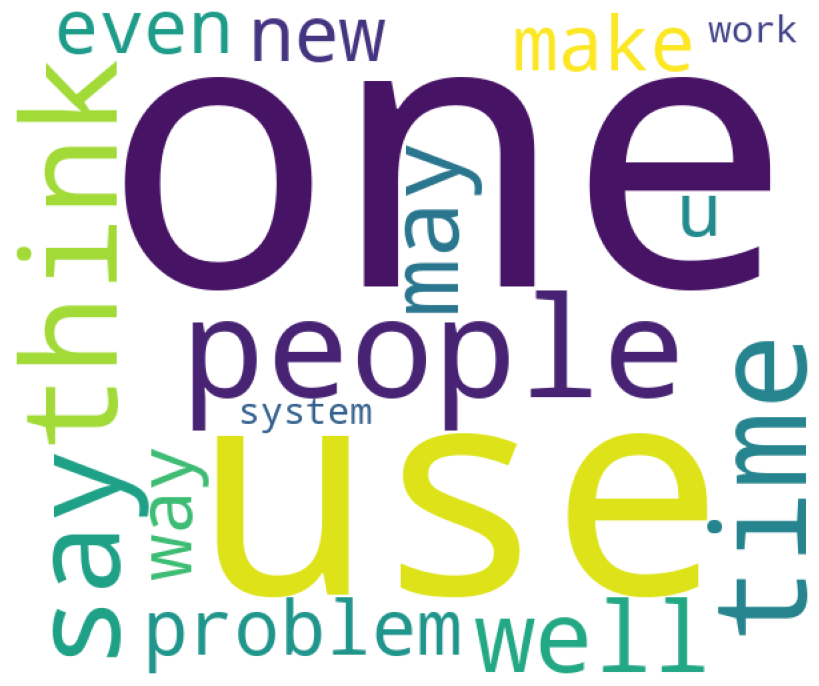

In [8]:
import matplotlib.pyplot as plt
#!pip install wordcloud
from wordcloud import WordCloud

# Combine all preprocessed text from the entire dataset
all_text = ' '.join(newsgroups_train_preprocessed + newsgroups_test_preprocessed)

# Generating the word cloud
wordcloud = WordCloud(width = 600, height = 500,
                      background_color ='white',
                      min_font_size = 10).generate(all_text)

# Ploting the word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()


/tmp/ipykernel_688/435439896.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='category_name', order=df['category_name'].value_counts().index, palette="viridis")


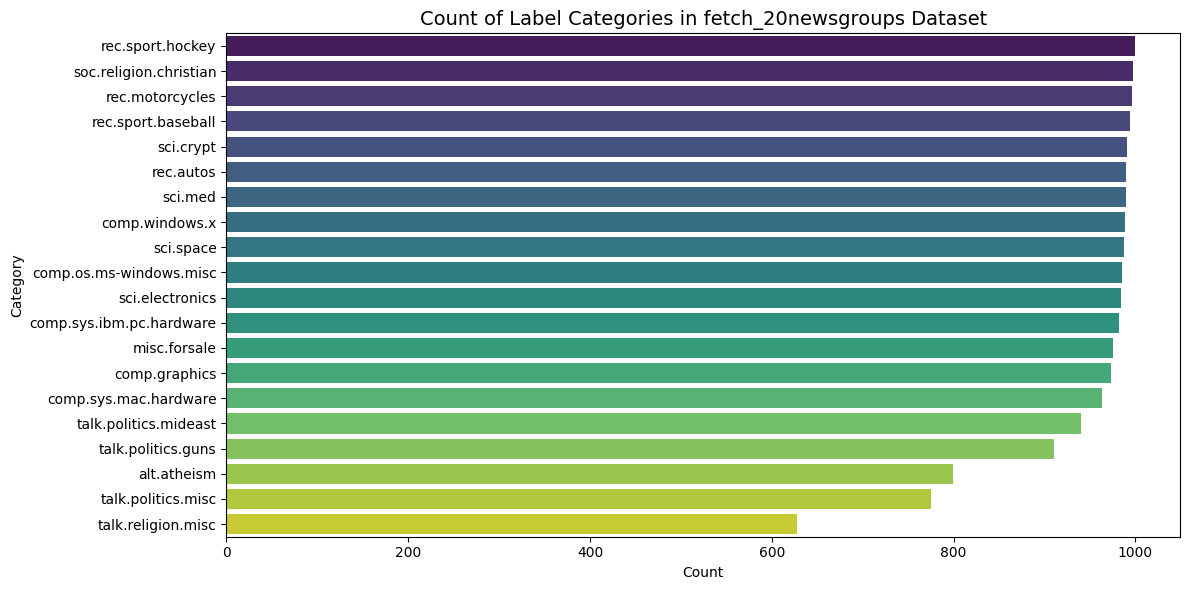

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to a DataFrame for easier manipulation
df = pd.DataFrame({'text': newsgroups.data, 'category': newsgroups.target})

# Mapping category indices to category names
df['category_name'] = df['category'].map(lambda x: newsgroups.target_names[x])

# Count plot for categories
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='category_name', order=df['category_name'].value_counts().index, palette="viridis")
plt.title("Count of Label Categories in fetch_20newsgroups Dataset", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


# **Model Training**

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train = vectorizer.fit_transform(newsgroups_train_preprocessed)

X_test = vectorizer.transform(newsgroups_test_preprocessed)

y_train = newsgroups_train.target
y_test = newsgroups_test.target

**Multi Modal Naive Bayes**

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,accuracy_score

# Train the model
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# Predict on test data
y_pred = model_nb.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred, target_names=newsgroups_train.target_names))
print("Accuracy:", accuracy_score(y_test, y_pred))

                          precision    recall  f1-score   support

             alt.atheism       0.56      0.33      0.41       319
           comp.graphics       0.56      0.64      0.60       389
 comp.os.ms-windows.misc       0.59      0.62      0.61       394
comp.sys.ibm.pc.hardware       0.60      0.65      0.62       392
   comp.sys.mac.hardware       0.70      0.58      0.63       385
          comp.windows.x       0.74      0.70      0.72       395
            misc.forsale       0.73      0.77      0.75       390
               rec.autos       0.73      0.67      0.70       396
         rec.motorcycles       0.69      0.71      0.70       398
      rec.sport.baseball       0.78      0.76      0.77       397
        rec.sport.hockey       0.53      0.88      0.67       399
               sci.crypt       0.73      0.69      0.71       396
         sci.electronics       0.61      0.47      0.53       393
                 sci.med       0.77      0.71      0.74       396
         

**Logistic Regression**

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score

# Train the model
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

# Predict on test data
y_pred = model_lr.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred, target_names=newsgroups_train.target_names))
print("Accuracy:", accuracy_score(y_test, y_pred))

                          precision    recall  f1-score   support

             alt.atheism       0.45      0.45      0.45       319
           comp.graphics       0.59      0.62      0.60       389
 comp.os.ms-windows.misc       0.61      0.60      0.60       394
comp.sys.ibm.pc.hardware       0.62      0.59      0.60       392
   comp.sys.mac.hardware       0.70      0.62      0.66       385
          comp.windows.x       0.75      0.67      0.71       395
            misc.forsale       0.73      0.76      0.74       390
               rec.autos       0.67      0.63      0.65       396
         rec.motorcycles       0.44      0.74      0.55       398
      rec.sport.baseball       0.76      0.74      0.75       397
        rec.sport.hockey       0.88      0.83      0.85       399
               sci.crypt       0.83      0.64      0.72       396
         sci.electronics       0.50      0.54      0.52       393
                 sci.med       0.72      0.73      0.72       396
         

**Random Forest**

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score

# Train the model
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

# Predict on test data
y_pred = model_rf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred, target_names=newsgroups_train.target_names))
print("Accuracy:", accuracy_score(y_test, y_pred))

                          precision    recall  f1-score   support

             alt.atheism       0.40      0.30      0.34       319
           comp.graphics       0.52      0.55      0.53       389
 comp.os.ms-windows.misc       0.55      0.58      0.57       394
comp.sys.ibm.pc.hardware       0.57      0.51      0.53       392
   comp.sys.mac.hardware       0.60      0.59      0.59       385
          comp.windows.x       0.61      0.59      0.60       395
            misc.forsale       0.67      0.71      0.69       390
               rec.autos       0.39      0.63      0.48       396
         rec.motorcycles       0.65      0.63      0.64       398
      rec.sport.baseball       0.65      0.69      0.67       397
        rec.sport.hockey       0.73      0.78      0.75       399
               sci.crypt       0.75      0.61      0.67       396
         sci.electronics       0.41      0.39      0.40       393
                 sci.med       0.65      0.63      0.64       396
         

# **Custom Testing**

In [28]:
# Custom articles for testing
custom_articles = [
    """
NASA has announced a new mission to explore Mars. The mission aims to study the planet's surface,
climate, and potential for hosting life. Scientists are particularly excited about collecting rock
samples from regions believed to have ancient water flow.
""",
    """
I'm having trouble with my new graphics card. After installing the latest drivers, I'm experiencing
frequent crashes when playing games. It's an NVIDIA RTX series card, and I'm running Windows 11.
Any suggestions for troubleshooting?
""",
    """
Baseball season is in full swing! The Yankees are looking strong this year, with their star pitcher
dominating the mound. Fans are eagerly awaiting the playoffs, hoping for a World Series victory.
"""
]

# Dictionary to store predictions for comparison
predictions = {"Multinomial Naive Bayes": [], "Logistic Regression": [], "Random Forest": []}

for i, custom_article in enumerate(custom_articles):
    print(f"\n--- Article {i+1} ---")
    print(f"Original: {custom_article[:100]}...") # Print first 100 chars of original article

    # Preprocess the article
    preprocessed_article = preprocess_text(custom_article)
    custom_article_vectorized = vectorizer.transform([preprocessed_article])

    # Predict with Multinomial Naive Bayes
    predicted_category_nb = model_nb.predict(custom_article_vectorized)
    category_name_nb = newsgroups_train.target_names[predicted_category_nb[0]]
    predictions["Multinomial Naive Bayes"].append(category_name_nb)
    print("Multinomial Naive Bayes Predicted Category:", category_name_nb)

    # Predict with Logistic Regression
    predicted_category_lr = model_lr.predict(custom_article_vectorized)
    category_name_lr = newsgroups_train.target_names[predicted_category_lr[0]]
    predictions["Logistic Regression"].append(category_name_lr)
    print("Logistic Regression Predicted Category:", category_name_lr)

    # Predict with Random Forest
    predicted_category_rf = model_rf.predict(custom_article_vectorized)
    category_name_rf = newsgroups_train.target_names[predicted_category_rf[0]]
    predictions["Random Forest"].append(category_name_rf)
    print("Random Forest Predicted Category:", category_name_rf)

print("\n--- Comparison Summary ---")
for model_name, preds in predictions.items():
    print(f"{model_name}: {preds}")


--- Article 1 ---
Original: 
NASA has announced a new mission to explore Mars. The mission aims to study the planet's surface,
c...
Multinomial Naive Bayes Predicted Category: sci.space
Logistic Regression Predicted Category: sci.space
Random Forest Predicted Category: sci.space

--- Article 2 ---
Original: 
I'm having trouble with my new graphics card. After installing the latest drivers, I'm experiencing...
Multinomial Naive Bayes Predicted Category: comp.os.ms-windows.misc
Logistic Regression Predicted Category: comp.os.ms-windows.misc
Random Forest Predicted Category: comp.os.ms-windows.misc

--- Article 3 ---
Original: 
Baseball season is in full swing! The Yankees are looking strong this year, with their star pitcher...
Multinomial Naive Bayes Predicted Category: rec.sport.baseball
Logistic Regression Predicted Category: rec.sport.baseball
Random Forest Predicted Category: rec.sport.baseball

--- Comparison Summary ---
Multinomial Naive Bayes: ['sci.space', 'comp.os.ms-windows.m